## Initial thoughts before starting

There are several possible outcomes in the Stage 6 files:

- yearly collision count;
- yearly hotspot status;
- number of hotspot years;
- persistence score;
- persistent-hotspot membership;
- temporal pattern category.

I do not think it is necessary to model all of them because several are calculated from the same annual hotspot results.

For this stage, I will mainly use:

- **yearly hotspot status** for logistic regression;
- **yearly collision count** for count regression.

The persistence and temporal-pattern variables will still be reviewed, but I will not force a separate model for every derived outcome.

## Important issue I noticed

The annual hotspot label was created from the annual collision count.

This means that using the current year's collision count to explain the current year's hotspot status would be circular. It would almost guarantee a strong result without adding useful knowledge.

To avoid this, I will create previous-year variables and ask a more sensible question:

> Is collision activity in the previous year associated with hotspot status or collision volume in the following year?

## Connect Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import the libraries

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Set the file paths

In [3]:
yearly_file = "/content/drive/MyDrive/disseration/stage6_outputs/grid_year_hotspots_5km.csv"

persistence_file = "/content/drive/MyDrive/disseration/stage6_outputs/grid_persistence_5km.csv"

stage7_folder = "/content/drive/MyDrive/disseration/stage7_outputs"

os.makedirs(stage7_folder, exist_ok=True)

print("Stage 7 output folder:")
print(stage7_folder)

Stage 7 output folder:
/content/drive/MyDrive/disseration/stage7_outputs


## Load the Stage 6 files

I am using the CSV files because geometry is not needed for fitting the statistical models.

In [4]:
yearly = pd.read_csv(yearly_file)
persistence = pd.read_csv(persistence_file)

print("Yearly data shape:", yearly.shape)
print("Persistence data shape:", persistence.shape)

Yearly data shape: (38030, 20)
Persistence data shape: (7606, 25)


## First look at the yearly file

In [5]:
yearly.head()

,grid_id,year,collision_count,fatal_count,serious_count,slight_count,total_severity_score,mean_severity_score,occupied_in_year,zero_collision_year,grid_row,grid_col,cell_size_m,cell_area_km2,centroid_easting,centroid_northing,collision_percentile,hotspot_score,hotspot_count_threshold,is_hotspot
0,R000_C005,2020,0,0,0,0,0.0000,NaN,0,1,0,5,5000,25.0000,"92,500.0000","12,500.0000",0.0000,0.0000,32,0
1,R000_C005,2021,0,0,0,0,0.0000,NaN,0,1,0,5,5000,25.0000,"92,500.0000","12,500.0000",0.0000,0.0000,34,0
2,R000_C005,2022,2,0,0,2,2.0000,1.0000,1,0,0,5,5000,25.0000,"92,500.0000","12,500.0000",0.2670,26.7000,36,0
3,R000_C005,2023,3,0,1,2,4.0000,1.3333,1,0,0,5,5000,25.0000,"92,500.0000","12,500.0000",0.3855,38.5500,35,0
4,R000_C005,2024,2,0,2,0,4.0000,2.0000,1,0,0,5,5000,25.0000,"92,500.0000","12,500.0000",0.2644,26.4400,34,0


## First look at the persistence file

In [6]:
persistence.head()

,grid_id,hotspot_2020,hotspot_2021,hotspot_2022,hotspot_2023,hotspot_2024,hotspot_years,hotspot_proportion,persistence_score,persistence_category,longest_hotspot_run,early_hotspot_years,late_hotspot_years,early_hotspot_rate,late_hotspot_rate,hotspot_change_score,collision_count_2020,collision_count_2021,collision_count_2022,collision_count_2023,collision_count_2024,early_mean_collision_count,late_mean_collision_count,collision_count_change,pattern_category
0,R000_C005,0,0,0,0,0,0,0.0000,0.0000,Never hotspot,0,0,0,0.0000,0.0000,0.0000,0,0,2,3,2,0.0000,2.5000,2.5000,Never hotspot
1,R000_C021,0,0,0,0,0,0,0.0000,0.0000,Never hotspot,0,0,0,0.0000,0.0000,0.0000,1,1,0,2,0,1.0000,1.0000,0.0000,Never hotspot
2,R001_C020,0,0,0,0,0,0,0.0000,0.0000,Never hotspot,0,0,0,0.0000,0.0000,0.0000,2,4,2,4,2,3.0000,3.0000,0.0000,Never hotspot
3,R001_C021,0,0,0,0,0,0,0.0000,0.0000,Never hotspot,0,0,0,0.0000,0.0000,0.0000,4,2,3,1,0,3.0000,0.5000,-2.5000,Never hotspot
4,R001_C022,0,0,0,0,0,0,0.0000,0.0000,Never hotspot,0,0,0,0.0000,0.0000,0.0000,3,4,0,0,1,3.5000,0.5000,-3.0000,Never hotspot


## Check the column names

I want to see what was actually saved before deciding which explanatory variables can be used.

In [7]:
print("Yearly file columns:")
for col in yearly.columns:
    print(col)

Yearly file columns:
grid_id
year
collision_count
fatal_count
serious_count
slight_count
total_severity_score
mean_severity_score
occupied_in_year
zero_collision_year
grid_row
grid_col
cell_size_m
cell_area_km2
centroid_easting
centroid_northing
collision_percentile
hotspot_score
hotspot_count_threshold
is_hotspot


In [8]:
print("Persistence file columns:")
for col in persistence.columns:
    print(col)

Persistence file columns:
grid_id
hotspot_2020
hotspot_2021
hotspot_2022
hotspot_2023
hotspot_2024
hotspot_years
hotspot_proportion
persistence_score
persistence_category
longest_hotspot_run
early_hotspot_years
late_hotspot_years
early_hotspot_rate
late_hotspot_rate
hotspot_change_score
collision_count_2020
collision_count_2021
collision_count_2022
collision_count_2023
collision_count_2024
early_mean_collision_count
late_mean_collision_count
collision_count_change
pattern_category


## Check the basic structure

The yearly file should contain one record for each grid cell and year.

In [9]:
print("Number of rows:", len(yearly))
print("Number of grid cells:", yearly["grid_id"].nunique())
print("Years:", sorted(yearly["year"].dropna().unique()))
print("Duplicate grid-year rows:", yearly.duplicated(["grid_id", "year"]).sum())

Number of rows: 38030
Number of grid cells: 7606
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Duplicate grid-year rows: 0


In [10]:
year_counts = yearly.groupby("grid_id")["year"].nunique()

print("Number of yearly records per grid cell:")
print(year_counts.value_counts().sort_index())

Number of yearly records per grid cell:
year
5    7606
Name: count, dtype: int64


The result should mainly show five yearly records per grid cell. If some cells have fewer records, I would need to check whether rows were lost earlier.

## Check the required modelling columns

In [11]:
needed = ["grid_id", "year", "collision_count", "is_hotspot"]

missing_needed = [col for col in needed if col not in yearly.columns]

if len(missing_needed) > 0:
    print("Missing required columns:", missing_needed)
else:
    print("All required columns are available.")

All required columns are available.


## Make sure the main variables have sensible data types

In [12]:
yearly["grid_id"] = yearly["grid_id"].astype(str)

yearly["year"] = pd.to_numeric(yearly["year"], errors="coerce")
yearly["collision_count"] = pd.to_numeric(yearly["collision_count"], errors="coerce")
yearly["is_hotspot"] = pd.to_numeric(yearly["is_hotspot"], errors="coerce")

yearly[["grid_id", "year", "collision_count", "is_hotspot"]].dtypes

,0
grid_id,object
year,int64
collision_count,int64
is_hotspot,int64


## Quick missing-value check

In [13]:
yearly[["grid_id", "year", "collision_count", "is_hotspot"]].isna().sum()

,0
grid_id,0
year,0
collision_count,0
is_hotspot,0


## Check the hotspot values

In [14]:
print(yearly["is_hotspot"].value_counts(dropna=False).sort_index())

is_hotspot
0    34949
1     3081
Name: count, dtype: int64


The hotspot outcome should only contain 0 and 1. I am checking this before carrying out any modelling.

In [15]:
valid_hotspot = yearly["is_hotspot"].dropna().isin([0, 1]).all()

print("Only 0 and 1 are present:", valid_hotspot)

Only 0 and 1 are present: True


## Review collision counts by year

In [16]:
yearly_count_summary = (
    yearly.groupby("year")
    .agg(
        grid_cells=("grid_id", "size"),
        total_collisions=("collision_count", "sum"),
        mean_collisions=("collision_count", "mean"),
        median_collisions=("collision_count", "median"),
        variance_collisions=("collision_count", "var"),
        zero_count_cells=("collision_count", lambda x: (x == 0).sum()),
        hotspot_cells=("is_hotspot", "sum")
    )
    .reset_index()
)

yearly_count_summary["hotspot_percent"] = (
    yearly_count_summary["hotspot_cells"]
    / yearly_count_summary["grid_cells"]
    * 100
)

yearly_count_summary.round(3)

,year,grid_cells,total_collisions,mean_collisions,median_collisions,variance_collisions,zero_count_cells,hotspot_cells,hotspot_percent
0,2020,7606,91185,11.9890,3.0000,"2,007.7510",1659,601,7.9020
1,2021,7606,101070,13.2880,3.0000,"2,594.9670",1538,612,8.0460
2,2022,7606,105982,13.9340,3.0000,"2,685.5960",1513,610,8.0200
3,2023,7606,104246,13.7060,3.0000,"2,576.2310",1471,629,8.2700
4,2024,7606,100927,13.2690,3.0000,"2,183.6600",1469,629,8.2700


I am comparing the mean and variance because this will later help me decide whether Poisson regression is realistic.

In [17]:
overall_mean = yearly["collision_count"].mean()
overall_variance = yearly["collision_count"].var()

print("Overall mean:", round(overall_mean, 3))
print("Overall variance:", round(overall_variance, 3))
print("Variance-to-mean ratio:", round(overall_variance / overall_mean, 3))

Overall mean: 13.237
Overall variance: 2409.841
Variance-to-mean ratio: 182.051


## Plot the collision-count distribution

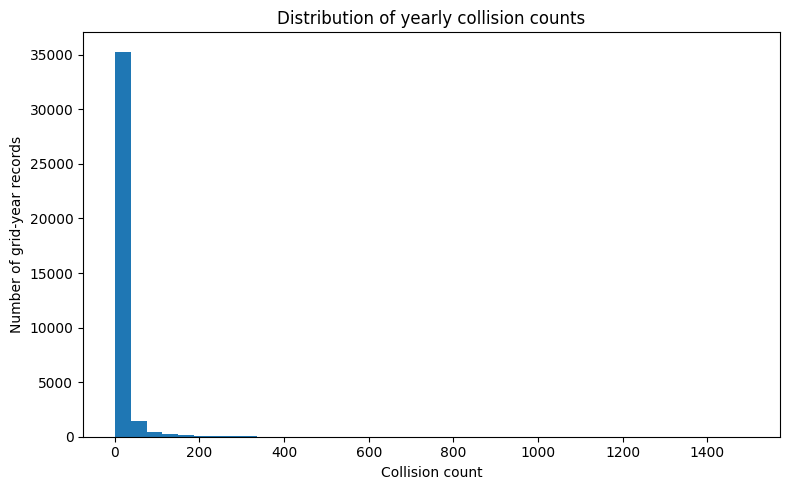

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    yearly["collision_count"].dropna(),
    bins=40
)

plt.title("Distribution of yearly collision counts")
plt.xlabel("Collision count")
plt.ylabel("Number of grid-year records")

plt.tight_layout()
plt.show()

The distribution may be strongly right-skewed because a small number of urban grid cells can contain many collisions.

## Plot collision counts by year

<Figure size 800x500 with 0 Axes>

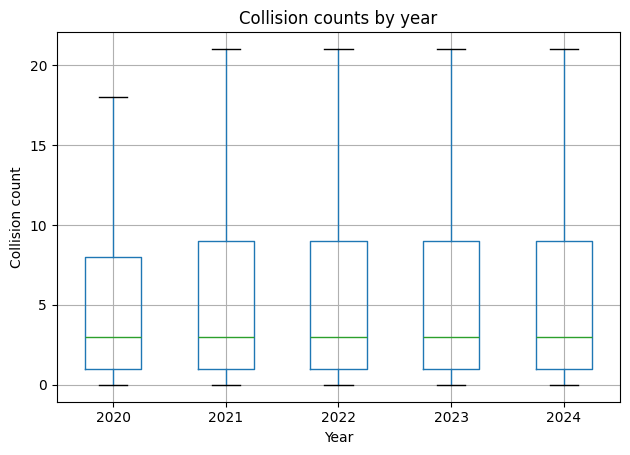

In [19]:
plt.figure(figsize=(8, 5))

yearly.boxplot(
    column="collision_count",
    by="year",
    showfliers=False
)

plt.suptitle("")
plt.title("Collision counts by year")
plt.xlabel("Year")
plt.ylabel("Collision count")

plt.tight_layout()
plt.show()

## Review hotspot frequency by year

In [20]:
hotspot_by_year = (
    yearly.groupby("year")["is_hotspot"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

hotspot_by_year["hotspot_percent"] = hotspot_by_year["mean"] * 100

hotspot_by_year

,year,count,sum,mean,hotspot_percent
0,2020,7606,601,0.0790,7.9017
1,2021,7606,612,0.0805,8.0463
2,2022,7606,610,0.0802,8.0200
3,2023,7606,629,0.0827,8.2698
4,2024,7606,629,0.0827,8.2698


## Review the grid-level persistence outcomes

These variables are useful for describing the final hotspot patterns, even though I am not using all of them as separate regression outcomes.

In [21]:
possible_persistence_cols = [
    "hotspot_years",
    "persistence_score",
    "persistence_category",
    "pattern_category",
    "longest_hotspot_run"
]

available_persistence_cols = [
    col for col in possible_persistence_cols
    if col in persistence.columns
]

print("Available persistence variables:")
print(available_persistence_cols)

Available persistence variables:
['hotspot_years', 'persistence_score', 'persistence_category', 'pattern_category', 'longest_hotspot_run']


In [22]:
if "persistence_category" in persistence.columns:
    display(
        persistence["persistence_category"]
        .value_counts(dropna=False)
        .rename_axis("persistence_category")
        .reset_index(name="grid_cells")
    )

,persistence_category,grid_cells
0,Never hotspot,6844
1,Persistent hotspot,554
2,Repeated hotspot,122
3,Occasional hotspot,86


In [23]:
if "pattern_category" in persistence.columns:
    display(
        persistence["pattern_category"]
        .value_counts(dropna=False)
        .rename_axis("pattern_category")
        .reset_index(name="grid_cells")
    )

,pattern_category,grid_cells
0,Never hotspot,6844
1,Persistent,554
2,Intermittent,79
3,Emerging,78
4,Declining,51


At this stage I am keeping these as descriptive outcomes. A multinomial model for the pattern categories is possible, but it would make the analysis much larger and may be unstable if some categories contain few grid cells.

## Look for possible explanatory variables

I do not want to assume that every Stage 5 variable was saved. I will first separate obvious identifiers and outcome variables from possible predictors.

In [24]:
not_predictors = [
    "grid_id",
    "year",
    "collision_count",
    "is_hotspot",
    "hotspot_score",
    "percentile_rank",
    "hotspot_threshold",
    "geometry"
]

possible_predictors = [
    col for col in yearly.columns
    if col not in not_predictors
]

print("Possible predictors found in the yearly file:")
print(possible_predictors)

Possible predictors found in the yearly file:
['fatal_count', 'serious_count', 'slight_count', 'total_severity_score', 'mean_severity_score', 'occupied_in_year', 'zero_collision_year', 'grid_row', 'grid_col', 'cell_size_m', 'cell_area_km2', 'centroid_easting', 'centroid_northing', 'collision_percentile', 'hotspot_count_threshold']


Some of these may still be derived hotspot variables, so I need to inspect their data types and unique values before using them.

In [25]:
predictor_check = pd.DataFrame({
    "column": possible_predictors,
    "data_type": [str(yearly[col].dtype) for col in possible_predictors],
    "missing": [yearly[col].isna().sum() for col in possible_predictors],
    "unique_values": [yearly[col].nunique(dropna=True) for col in possible_predictors]
})

predictor_check

,column,data_type,missing,unique_values
0,fatal_count,int64,0,9
1,serious_count,int64,0,136
2,slight_count,int64,0,353
3,total_severity_score,float64,0,447
4,mean_severity_score,float64,7650,1359
5,occupied_in_year,int64,0,2
6,zero_collision_year,int64,0,2
7,grid_row,int64,0,218
8,grid_col,int64,0,118
9,cell_size_m,int64,0,1


For the main model, I will definitely use previous-year collision activity because it is available and directly linked to the temporal research question.

If road, severity or environmental summary variables are present, they can be added later as an extended model. I will first fit a simple and understandable model.

## Sort the data before creating previous-year values

In [26]:
yearly = yearly.sort_values(["grid_id", "year"]).reset_index(drop=True)

yearly[["grid_id", "year", "collision_count", "is_hotspot"]].head(10)

,grid_id,year,collision_count,is_hotspot
0,R000_C005,2020,0,0
1,R000_C005,2021,0,0
2,R000_C005,2022,2,0
3,R000_C005,2023,3,0
4,R000_C005,2024,2,0
5,R000_C021,2020,1,0
6,R000_C021,2021,1,0
7,R000_C021,2022,0,0
8,R000_C021,2023,2,0
9,R000_C021,2024,0,0


## Create previous-year collision count and hotspot status

In [27]:
yearly["previous_count"] = (
    yearly.groupby("grid_id")["collision_count"]
    .shift(1)
)

yearly["previous_hotspot"] = (
    yearly.groupby("grid_id")["is_hotspot"]
    .shift(1)
)

## Check one grid cell to make sure the lag worked

In [28]:
one_grid = yearly["grid_id"].iloc[0]

yearly.loc[
    yearly["grid_id"] == one_grid,
    [
        "grid_id",
        "year",
        "collision_count",
        "previous_count",
        "is_hotspot",
        "previous_hotspot"
    ]
]

,grid_id,year,collision_count,previous_count,is_hotspot,previous_hotspot
0,R000_C005,2020,0,NaN,0,NaN
1,R000_C005,2021,0,0.0000,0,0.0000
2,R000_C005,2022,2,0.0000,0,0.0000
3,R000_C005,2023,3,2.0000,0,0.0000
4,R000_C005,2024,2,3.0000,0,0.0000


The first year has no previous-year value, which is expected. The lagged models will therefore use 2021 to 2024.

## Log-transform the previous collision count

In [29]:
yearly["log_previous_count"] = np.log1p(yearly["previous_count"])

I used `log1p()` because previous collision count is right-skewed and may include zero. This calculates log(1 + count), so zero values remain usable.

## Create the modelling data

In [30]:
model_df = yearly.dropna(
    subset=[
        "previous_count",
        "previous_hotspot",
        "collision_count",
        "is_hotspot",
        "year"
    ]
).copy()

model_df["year"] = model_df["year"].astype(int)
model_df["is_hotspot"] = model_df["is_hotspot"].astype(int)
model_df["previous_hotspot"] = model_df["previous_hotspot"].astype(int)

print("Rows available for modelling:", len(model_df))
print("Unique grid cells:", model_df["grid_id"].nunique())
print("Years used:", sorted(model_df["year"].unique()))

Rows available for modelling: 30424
Unique grid cells: 7606
Years used: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## Check missing values in the selected variables

In [31]:
selected_vars = [
    "grid_id",
    "year",
    "collision_count",
    "is_hotspot",
    "previous_count",
    "log_previous_count",
    "previous_hotspot"
]

model_df[selected_vars].isna().sum()

,0
grid_id,0
year,0
collision_count,0
is_hotspot,0
previous_count,0
log_previous_count,0
previous_hotspot,0


# Simple statistical tests before regression

I am starting with simple two-variable tests so that I can understand the relationships before fitting regression models.

## Chi-square test

I will test whether current hotspot status is associated with previous-year hotspot status.

Both variables are categorical with two levels, so a chi-square test is suitable.

In [32]:
hotspot_table = pd.crosstab(
    model_df["previous_hotspot"],
    model_df["is_hotspot"]
)

hotspot_table

is_hotspot,0,1
previous_hotspot,,
0,27699,273
1,245,2207


In [33]:
chi2, chi_p, chi_df, expected = chi2_contingency(hotspot_table)

print("Chi-square statistic:", round(chi2, 4))
print("Degrees of freedom:", chi_df)
print("p-value:", chi_p)
print("Smallest expected count:", expected.min())

Chi-square statistic: 23856.002
Degrees of freedom: 1
p-value: 0.0
Smallest expected count: 199.87378385485144


I will also calculate Cramér's V because a p-value only tells me whether there is evidence of an association. It does not show the size of the association.

In [34]:
n = hotspot_table.to_numpy().sum()
rows, columns = hotspot_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(rows - 1, columns - 1))
)

print("Cramer's V:", round(cramers_v, 4))

Cramer's V: 0.8855


## Mann-Whitney U test

Next, I will compare previous-year collision counts between current hotspot and non-hotspot observations.

The count distribution is unlikely to be normal, so I am using Mann-Whitney U instead of an independent-samples t-test.

In [35]:
hotspot_previous_counts = model_df.loc[
    model_df["is_hotspot"] == 1,
    "previous_count"
]

nonhotspot_previous_counts = model_df.loc[
    model_df["is_hotspot"] == 0,
    "previous_count"
]

print("Current hotspot median previous count:",
      hotspot_previous_counts.median())

print("Current non-hotspot median previous count:",
      nonhotspot_previous_counts.median())

Current hotspot median previous count: 62.0
Current non-hotspot median previous count: 2.0


In [36]:
u_stat, u_p = mannwhitneyu(
    hotspot_previous_counts,
    nonhotspot_previous_counts,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", round(u_stat, 2))
print("p-value:", u_p)

Mann-Whitney U statistic: 69085376.0
p-value: 0.0


## Calculate a simple effect size for Mann-Whitney U

In [37]:
n1 = len(hotspot_previous_counts)
n2 = len(nonhotspot_previous_counts)

rank_biserial = (2 * u_stat) / (n1 * n2) - 1

print("Rank-biserial correlation:", round(rank_biserial, 4))

Rank-biserial correlation: 0.9938


## Kruskal-Wallis test across years

I will check whether the collision-count distribution changes across the model years.

Kruskal-Wallis is suitable because there are more than two year groups and the outcome is skewed.

In [38]:
year_groups = []

for year_value in sorted(model_df["year"].unique()):
    year_groups.append(
        model_df.loc[
            model_df["year"] == year_value,
            "collision_count"
        ]
    )

kw_stat, kw_p = kruskal(*year_groups)

print("Kruskal-Wallis statistic:", round(kw_stat, 4))
print("p-value:", kw_p)

Kruskal-Wallis statistic: 5.5175
p-value: 0.13759758343865422


## Approximate effect size for the Kruskal-Wallis test

In [39]:
k = model_df["year"].nunique()
n_total = len(model_df)

epsilon_squared = max(
    0,
    (kw_stat - k + 1) / (n_total - k)
)

print("Epsilon-squared:", round(epsilon_squared, 4))

Epsilon-squared: 0.0001


# Correlation and multicollinearity

Before fitting the models, I will check whether the numerical explanatory variables are strongly related to each other.

In [40]:
corr_cols = [
    "previous_count",
    "log_previous_count",
    "previous_hotspot"
]

model_df[corr_cols].corr(method="spearman").round(3)

,previous_count,log_previous_count,previous_hotspot
previous_count,1.0000,1.0000,0.4750
log_previous_count,1.0000,1.0000,0.4750
previous_hotspot,0.4750,0.4750,1.0000


`previous_hotspot` was created from the previous collision count, so these two variables overlap.

I will therefore avoid putting `previous_hotspot` and `log_previous_count` in the same main model. Instead, I will fit them in separate models.

## VIF check for the main logistic model

In [41]:
vif_df = model_df[
    ["log_previous_count", "year"]
].copy()

vif_df["year"] = vif_df["year"].astype(str)

vif_df = pd.get_dummies(
    vif_df,
    columns=["year"],
    drop_first=True,
    dtype=float
)

vif_df = sm.add_constant(vif_df)

vif_results = []

for i, col in enumerate(vif_df.columns):
    if col != "const":
        vif_results.append({
            "variable": col,
            "VIF": variance_inflation_factor(
                vif_df.values,
                i
            )
        })

vif_results = pd.DataFrame(vif_results)

vif_results

,variable,VIF
0,log_previous_count,1.0009
1,year_2022,1.5004
2,year_2023,1.5009
3,year_2024,1.5010


As a general guide, VIF values above 5 would make me look more carefully at multicollinearity. This is not a strict rule, but it is useful as a warning.

# Logistic regression for yearly hotspot status

The outcome `is_hotspot` is binary, so logistic regression is appropriate.

The main explanatory variable will be the logged previous-year collision count. Year will be included as a categorical control variable.

## First fit a simple ordinary logistic model

In [42]:
logit_simple = smf.glm(
    formula="is_hotspot ~ log_previous_count + C(year)",
    data=model_df,
    family=sm.families.Binomial()
).fit()

print(logit_simple.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             is_hotspot   No. Observations:                30424
Model:                            GLM   Df Residuals:                    30419
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1155.1
Date:                Thu, 06 Aug 2026   Deviance:                       2310.2
Time:                        11:03:02   Pearson chi2:                 5.10e+03
No. Iterations:                    11   Pseudo R-squ. (CS):             0.3867
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -24.7252      0

This ordinary model treats every row as independent. However, the same grid cell appears in several years, so that assumption is not fully realistic.

I will keep the same coefficient estimates but calculate standard errors clustered by grid cell.

## Refit with standard errors clustered by grid cell

In [43]:
logit_cluster = smf.glm(
    formula="is_hotspot ~ log_previous_count + C(year)",
    data=model_df,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_df["grid_id"]}
)

print(logit_cluster.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             is_hotspot   No. Observations:                30424
Model:                            GLM   Df Residuals:                    30419
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1155.1
Date:                Thu, 06 Aug 2026   Deviance:                       2310.2
Time:                        11:03:03   Pearson chi2:                 5.10e+03
No. Iterations:                    11   Pseudo R-squ. (CS):             0.3867
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -24.7252      0

Clustered standard errors allow observations from the same grid cell to be related over time. This is more suitable than treating all grid-year rows as completely independent.

## Convert the logistic coefficients into odds ratios

In [44]:
logit_ci = logit_cluster.conf_int()

logit_table = pd.DataFrame({
    "term": logit_cluster.params.index,
    "coefficient": logit_cluster.params.values,
    "standard_error": logit_cluster.bse.values,
    "p_value": logit_cluster.pvalues.values,
    "odds_ratio": np.exp(logit_cluster.params.values),
    "ci_lower": np.exp(logit_ci[0].values),
    "ci_upper": np.exp(logit_ci[1].values)
})

logit_table["significant_5_percent"] = (
    logit_table["p_value"] < 0.05
)

logit_table.round(4)

,term,coefficient,standard_error,p_value,odds_ratio,ci_lower,ci_upper,significant_5_percent
0,Intercept,-24.7252,0.7404,0.0000,0.0000,0.0000,0.0000,True
1,C(year)[T.2022],-0.6441,0.1693,0.0001,0.5251,0.3769,0.7317,True
2,C(year)[T.2023],-0.7122,0.1509,0.0000,0.4906,0.3649,0.6594,True
3,C(year)[T.2024],-0.6624,0.1407,0.0000,0.5156,0.3914,0.6793,True
4,log_previous_count,7.1011,0.2153,0.0000,"1,213.3287",795.6386,"1,850.2955",True


An odds ratio above 1 indicates higher odds of being a hotspot. An odds ratio below 1 indicates lower odds.

The p-value shows the strength of evidence against no association, while the confidence interval shows the uncertainty around the odds ratio.

## Calculate AIC and McFadden pseudo-R-squared

In [45]:
null_logit = smf.glm(
    formula="is_hotspot ~ 1",
    data=model_df,
    family=sm.families.Binomial()
).fit()

mcfadden_r2 = 1 - (
    logit_cluster.llf / null_logit.llf
)

print("AIC:", round(logit_cluster.aic, 3))
print("McFadden pseudo-R-squared:", round(mcfadden_r2, 4))

AIC: 2320.162
McFadden pseudo-R-squared: 0.8656


Pseudo-R-squared should not be interpreted in exactly the same way as ordinary linear-regression R-squared. I am using it only as a broad measure of improvement over an intercept-only model.

## Create some practical probability examples

In [46]:
example_counts = pd.DataFrame({
    "previous_count": [0, 1, 5, 10, 25, 50],
    "year": [2024, 2024, 2024, 2024, 2024, 2024]
})

example_counts["log_previous_count"] = np.log1p(
    example_counts["previous_count"]
)

example_counts["estimated_hotspot_probability"] = (
    logit_cluster.predict(example_counts)
)

example_counts

,previous_count,year,log_previous_count,estimated_hotspot_probability
0,0,2024,0.0000,0.0000
1,1,2024,0.6931,0.0000
2,5,2024,1.7918,0.0000
3,10,2024,2.3979,0.0002
4,25,2024,3.2581,0.0952
5,50,2024,3.9318,0.9264


This table is useful because an odds ratio can be difficult to explain in practical terms. The estimated probabilities show how hotspot probability changes across example previous-year collision counts.

## A second logistic model using previous hotspot status

I am fitting this separately because previous hotspot status already comes from previous collision count.

In [47]:
logit_previous_hotspot = smf.glm(
    formula="is_hotspot ~ previous_hotspot + C(year)",
    data=model_df,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_df["grid_id"]}
)

print(logit_previous_hotspot.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             is_hotspot   No. Observations:                30424
Model:                            GLM   Df Residuals:                    30419
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2331.1
Date:                Thu, 06 Aug 2026   Deviance:                       4662.3
Time:                        11:03:03   Pearson chi2:                 3.04e+04
No. Iterations:                     8   Pseudo R-squ. (CS):             0.3375
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -4.5995      0.104  

In [48]:
previous_hotspot_ci = logit_previous_hotspot.conf_int()

previous_hotspot_table = pd.DataFrame({
    "term": logit_previous_hotspot.params.index,
    "coefficient": logit_previous_hotspot.params.values,
    "p_value": logit_previous_hotspot.pvalues.values,
    "odds_ratio": np.exp(logit_previous_hotspot.params.values),
    "ci_lower": np.exp(previous_hotspot_ci[0].values),
    "ci_upper": np.exp(previous_hotspot_ci[1].values)
})

previous_hotspot_table.round(4)

,term,coefficient,p_value,odds_ratio,ci_lower,ci_upper
0,Intercept,-4.5995,0.0000,0.0101,0.0082,0.0123
1,C(year)[T.2022],-0.0969,0.5153,0.9076,0.6777,1.2154
2,C(year)[T.2023],0.0725,0.5553,1.0752,0.8450,1.3681
3,C(year)[T.2024],-0.0646,0.5882,0.9374,0.7419,1.1844
4,previous_hotspot,6.8221,0.0000,917.8890,708.7330,"1,188.7695"


The odds ratio for `previous_hotspot` gives a direct measure of short-term hotspot persistence from one year to the next.

## Try a GEE model as a repeated-measures check

Clustered standard errors adjust the uncertainty, but GEE also models the repeated observations as groups.

I am using an exchangeable correlation structure, which assumes a similar level of within-grid correlation between the yearly observations.

In [49]:
gee_logit = smf.gee(
    formula="is_hotspot ~ log_previous_count + C(year)",
    groups="grid_id",
    data=model_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()
).fit()

print(gee_logit.summary())

                               GEE Regression Results                              
Dep. Variable:                  is_hotspot   No. Observations:                30424
Model:                                 GEE   No. clusters:                     7606
Method:                        Generalized   Min. cluster size:                   4
                      Estimating Equations   Max. cluster size:                   4
Family:                           Binomial   Mean cluster size:                 4.0
Dependence structure:         Exchangeable   Num. iterations:                    10
Date:                     Thu, 06 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         11:03:08
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -26.4826      0.823    -32.159      0.000     -28

## Compare the main coefficient between the two approaches

In [50]:
comparison = pd.DataFrame({
    "model": [
        "Clustered logistic",
        "GEE logistic"
    ],
    "log_previous_count_coefficient": [
        logit_cluster.params["log_previous_count"],
        gee_logit.params["log_previous_count"]
    ],
    "standard_error": [
        logit_cluster.bse["log_previous_count"],
        gee_logit.bse["log_previous_count"]
    ],
    "p_value": [
        logit_cluster.pvalues["log_previous_count"],
        gee_logit.pvalues["log_previous_count"]
    ]
})

comparison

,model,log_previous_count_coefficient,standard_error,p_value
0,Clustered logistic,7.1011,0.2153,0.0000
1,GEE logistic,7.6251,0.2385,0.0000


If the direction and approximate size are similar, this gives more confidence that the main conclusion is not caused by one particular repeated-measures approach.

# Logistic model checks

There is no single diagnostic that proves a logistic model is correct, so I will look at several checks.

## Add fitted probabilities and Pearson residuals

In [51]:
model_df["logit_probability"] = logit_simple.fittedvalues
model_df["logit_residual"] = logit_simple.resid_pearson

model_df[
    ["logit_probability", "logit_residual"]
].describe()

,logit_probability,logit_residual
count,"30,424.0000","30,424.0000"
mean,0.0815,0.0010
std,0.2517,0.4094
min,0.0000,-5.2937
25%,0.0000,-0.0031
50%,0.0000,-0.0002
75%,0.0001,-0.0000
max,1.0000,34.4598


## Plot residuals against fitted probabilities

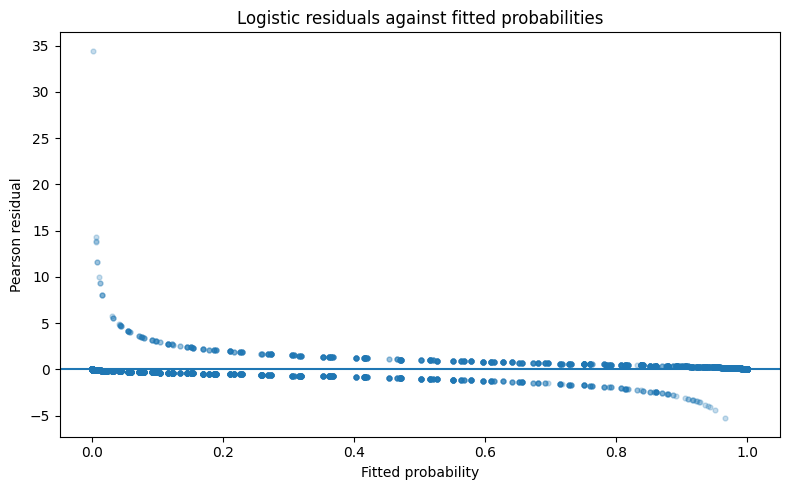

In [52]:
plt.figure(figsize=(8, 5))

plt.scatter(
    model_df["logit_probability"],
    model_df["logit_residual"],
    alpha=0.25,
    s=12
)

plt.axhline(0)
plt.title("Logistic residuals against fitted probabilities")
plt.xlabel("Fitted probability")
plt.ylabel("Pearson residual")

plt.tight_layout()
plt.show()

I am looking for a very strong systematic pattern. Some spread is expected because the outcome is binary.

## Check whether a squared term improves the functional form

In [53]:
logit_squared = smf.glm(
    formula=(
        "is_hotspot ~ log_previous_count "
        "+ I(log_previous_count ** 2) "
        "+ C(year)"
    ),
    data=model_df,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_df["grid_id"]}
)

print("Main model AIC:", round(logit_cluster.aic, 3))
print("Squared-term model AIC:", round(logit_squared.aic, 3))
print(
    "Squared-term p-value:",
    logit_squared.pvalues.get(
        "I(log_previous_count ** 2)",
        np.nan
    )
)

Main model AIC: 2320.162
Squared-term model AIC: 2321.067
Squared-term p-value: 0.1446569369781128


If the squared term is significant and the AIC is clearly lower, the relationship may not be fully represented by one straight line on the log-odds scale.

# Count regression for yearly collision count

The collision outcome is a non-negative count, so I will start with Poisson regression.

All grid cells cover the same 5 km by 5 km area and every row covers one year, so I do not need an exposure offset.

## Fit the Poisson model

In [54]:
poisson_simple = smf.glm(
    formula="collision_count ~ log_previous_count + C(year)",
    data=model_df,
    family=sm.families.Poisson()
).fit()

print(poisson_simple.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        collision_count   No. Observations:                30424
Model:                            GLM   Df Residuals:                    30419
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -73933.
Date:                Thu, 06 Aug 2026   Deviance:                       61008.
Time:                        11:03:09   Pearson chi2:                 5.97e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.1396      0

## Refit Poisson with clustered standard errors

In [55]:
poisson_cluster = smf.glm(
    formula="collision_count ~ log_previous_count + C(year)",
    data=model_df,
    family=sm.families.Poisson()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_df["grid_id"]}
)

print(poisson_cluster.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        collision_count   No. Observations:                30424
Model:                            GLM   Df Residuals:                    30419
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -73933.
Date:                Thu, 06 Aug 2026   Deviance:                       61008.
Time:                        11:03:09   Pearson chi2:                 5.97e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.1396      0

## Check for overdispersion

In [56]:
poisson_dispersion = (
    np.sum(poisson_simple.resid_pearson ** 2)
    / poisson_simple.df_resid
)

print("Poisson dispersion statistic:", round(poisson_dispersion, 4))

Poisson dispersion statistic: 1.963


A value close to 1 would support the Poisson assumption.

If the value is clearly above 1, especially above about 1.5, the data is overdispersed and Poisson standard errors and fit may be unsuitable.

## Convert Poisson coefficients to incidence rate ratios

In [57]:
poisson_ci = poisson_cluster.conf_int()

poisson_table = pd.DataFrame({
    "term": poisson_cluster.params.index,
    "coefficient": poisson_cluster.params.values,
    "standard_error": poisson_cluster.bse.values,
    "p_value": poisson_cluster.pvalues.values,
    "IRR": np.exp(poisson_cluster.params.values),
    "ci_lower": np.exp(poisson_ci[0].values),
    "ci_upper": np.exp(poisson_ci[1].values)
})

poisson_table.round(4)

,term,coefficient,standard_error,p_value,IRR,ci_lower,ci_upper
0,Intercept,-0.1396,0.0113,0.0000,0.8697,0.8506,0.8892
1,C(year)[T.2022],-0.0538,0.0087,0.0000,0.9477,0.9317,0.9639
2,C(year)[T.2023],-0.1158,0.0080,0.0000,0.8907,0.8767,0.9048
3,C(year)[T.2024],-0.1315,0.0082,0.0000,0.8768,0.8629,0.8910
4,log_previous_count,1.0410,0.0026,0.0000,2.8320,2.8178,2.8463


An incidence rate ratio above 1 means a higher expected collision count. An IRR below 1 means a lower expected count.

## Try negative binomial regression if Poisson is overdispersed

I am not choosing negative binomial automatically. I will only prefer it when the earlier dispersion check shows that Poisson is not suitable.

In [58]:
nb_model = None
nb_table = pd.DataFrame()

if poisson_dispersion > 1.5:
    nb_model = smf.negativebinomial(
        formula="collision_count ~ log_previous_count + C(year)",
        data=model_df
    ).fit(
        disp=False,
        maxiter=200,
        cov_type="cluster",
        cov_kwds={"groups": model_df["grid_id"]}
    )

    print(nb_model.summary())
else:
    print(
        "The Poisson dispersion was not strongly above 1.5, "
        "so negative binomial regression is not essential."
    )

                     NegativeBinomial Regression Results                      
Dep. Variable:        collision_count   No. Observations:                30424
Model:               NegativeBinomial   Df Residuals:                    30419
Method:                           MLE   Df Model:                            4
Date:                Thu, 06 Aug 2026   Pseudo R-squ.:                  0.2930
Time:                        11:03:09   Log-Likelihood:                -70627.
converged:                       True   LL-Null:                       -99899.
Covariance Type:              cluster   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.2623      0.009    -28.988      0.000      -0.280      -0.245
C(year)[T.2022]       -0.0218      0.011     -2.060      0.039      -0.043      -0.001
C(year)[T.2023]     

## Create the negative binomial IRR table when the model was fitted

In [59]:
if nb_model is not None:
    nb_ci = nb_model.conf_int()

    model_terms = [
        term for term in nb_model.params.index
        if term != "alpha"
    ]

    nb_table = pd.DataFrame({
        "term": model_terms,
        "coefficient": nb_model.params[model_terms].values,
        "standard_error": nb_model.bse[model_terms].values,
        "p_value": nb_model.pvalues[model_terms].values,
        "IRR": np.exp(nb_model.params[model_terms].values),
        "ci_lower": np.exp(nb_ci.loc[model_terms, 0].values),
        "ci_upper": np.exp(nb_ci.loc[model_terms, 1].values)
    })

    display(nb_table.round(4))

    print(
        "Estimated alpha:",
        round(nb_model.params["alpha"], 4)
    )

,term,coefficient,standard_error,p_value,IRR,ci_lower,ci_upper
0,Intercept,-0.2623,0.0090,0.0000,0.7693,0.7558,0.7831
1,C(year)[T.2022],-0.0218,0.0106,0.0394,0.9784,0.9583,0.9989
2,C(year)[T.2023],-0.0769,0.0090,0.0000,0.9260,0.9098,0.9425
3,C(year)[T.2024],-0.0790,0.0090,0.0000,0.9240,0.9078,0.9405
4,log_previous_count,1.0710,0.0021,0.0000,2.9183,2.9064,2.9302


Estimated alpha: 0.0967


## Compare AIC values

In [60]:
model_fit_rows = [{
    "model": "Poisson",
    "AIC": poisson_cluster.aic,
    "log_likelihood": poisson_cluster.llf
}]

if nb_model is not None:
    model_fit_rows.append({
        "model": "Negative binomial",
        "AIC": nb_model.aic,
        "log_likelihood": nb_model.llf
    })

count_model_fit = pd.DataFrame(model_fit_rows)

count_model_fit

,model,AIC,log_likelihood
0,Poisson,"147,875.8916","-73,932.9458"
1,Negative binomial,"141,265.6927","-70,626.8464"


A lower AIC indicates a better balance between fit and model complexity when the models use the same outcome and observations.

## Plot Poisson residuals

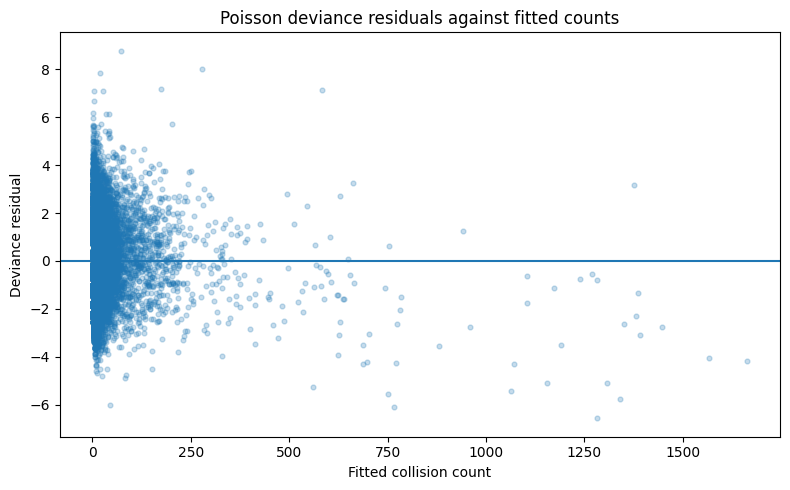

In [61]:
model_df["poisson_fitted"] = poisson_simple.fittedvalues
model_df["poisson_residual"] = poisson_simple.resid_deviance

plt.figure(figsize=(8, 5))

plt.scatter(
    model_df["poisson_fitted"],
    model_df["poisson_residual"],
    alpha=0.25,
    s=12
)

plt.axhline(0)
plt.title("Poisson deviance residuals against fitted counts")
plt.xlabel("Fitted collision count")
plt.ylabel("Deviance residual")

plt.tight_layout()
plt.show()

## Compare observed and predicted zero counts

In [62]:
observed_zero = (
    model_df["collision_count"] == 0
).mean()

poisson_mean = poisson_simple.predict(model_df)

predicted_zero_poisson = np.mean(
    np.exp(-poisson_mean)
)

print("Observed zero proportion:", round(observed_zero, 4))
print("Poisson predicted zero proportion:", round(predicted_zero_poisson, 4))

Observed zero proportion: 0.1969
Poisson predicted zero proportion: 0.1344


In [63]:
if nb_model is not None:
    nb_mean = nb_model.predict(model_df)
    alpha = nb_model.params["alpha"]

    predicted_zero_nb = np.mean(
        (1 + alpha * nb_mean) ** (-1 / alpha)
    )

    print(
        "Negative binomial predicted zero proportion:",
        round(predicted_zero_nb, 4)
    )

Negative binomial predicted zero proportion: 0.1593


If both models seriously underestimate the zero proportion, a zero-inflated or hurdle model could be considered. I am treating that as an optional sensitivity analysis rather than adding another complex model automatically.

# Pull the main results together

I will now create smaller result tables that are easier to transfer into the dissertation.

In [64]:
bivariate_summary = pd.DataFrame({
    "test": [
        "Chi-square",
        "Mann-Whitney U",
        "Kruskal-Wallis"
    ],
    "statistic": [
        chi2,
        u_stat,
        kw_stat
    ],
    "p_value": [
        chi_p,
        u_p,
        kw_p
    ],
    "effect_size": [
        cramers_v,
        rank_biserial,
        epsilon_squared
    ],
    "effect_size_name": [
        "Cramer's V",
        "Rank-biserial correlation",
        "Epsilon-squared"
    ]
})

bivariate_summary.round(5)

,test,statistic,p_value,effect_size,effect_size_name
0,Chi-square,"23,856.0020",0.0000,0.8855,Cramer's V
1,Mann-Whitney U,"69,085,376.0000",0.0000,0.9938,Rank-biserial correlation
2,Kruskal-Wallis,5.5175,0.1376,0.0001,Epsilon-squared


## Add simple significance wording

In [65]:
logit_table["interpretation"] = np.where(
    logit_table["p_value"] < 0.05,
    "Statistically significant at 5%",
    "Not statistically significant at 5%"
)

logit_table.round(4)

,term,coefficient,standard_error,p_value,odds_ratio,ci_lower,ci_upper,significant_5_percent,interpretation
0,Intercept,-24.7252,0.7404,0.0000,0.0000,0.0000,0.0000,True,Statistically significant at 5%
1,C(year)[T.2022],-0.6441,0.1693,0.0001,0.5251,0.3769,0.7317,True,Statistically significant at 5%
2,C(year)[T.2023],-0.7122,0.1509,0.0000,0.4906,0.3649,0.6594,True,Statistically significant at 5%
3,C(year)[T.2024],-0.6624,0.1407,0.0000,0.5156,0.3914,0.6793,True,Statistically significant at 5%
4,log_previous_count,7.1011,0.2153,0.0000,"1,213.3287",795.6386,"1,850.2955",True,Statistically significant at 5%


In [66]:
if nb_model is not None:
    chosen_count_model = "Negative binomial"
    chosen_count_table = nb_table.copy()
else:
    chosen_count_model = "Poisson"
    chosen_count_table = poisson_table.copy()

chosen_count_table["interpretation"] = np.where(
    chosen_count_table["p_value"] < 0.05,
    "Statistically significant at 5%",
    "Not statistically significant at 5%"
)

print("Selected count model:", chosen_count_model)

chosen_count_table.round(4)

Selected count model: Negative binomial


,term,coefficient,standard_error,p_value,IRR,ci_lower,ci_upper,interpretation
0,Intercept,-0.2623,0.0090,0.0000,0.7693,0.7558,0.7831,Statistically significant at 5%
1,C(year)[T.2022],-0.0218,0.0106,0.0394,0.9784,0.9583,0.9989,Statistically significant at 5%
2,C(year)[T.2023],-0.0769,0.0090,0.0000,0.9260,0.9098,0.9425,Statistically significant at 5%
3,C(year)[T.2024],-0.0790,0.0090,0.0000,0.9240,0.9078,0.9405,Statistically significant at 5%
4,log_previous_count,1.0710,0.0021,0.0000,2.9183,2.9064,2.9302,Statistically significant at 5%


## How I will interpret the results

For each important predictor, I will report:

- the direction of the coefficient;
- the odds ratio or incidence rate ratio;
- the 95% confidence interval;
- the p-value;
- whether the effect also appears practically important.

A statistically significant result does not automatically mean that the effect is large enough to matter in road-safety planning.

A non-significant result does not prove that there is no relationship. It means that the analysis did not find enough evidence at the selected significance level.

# Save the Stage 7 results

In [67]:
yearly_count_summary.to_csv(
    os.path.join(stage7_folder, "yearly_count_summary.csv"),
    index=False
)

bivariate_summary.to_csv(
    os.path.join(stage7_folder, "bivariate_test_results.csv"),
    index=False
)

vif_results.to_csv(
    os.path.join(stage7_folder, "vif_results.csv"),
    index=False
)

logit_table.to_csv(
    os.path.join(stage7_folder, "logistic_regression_results.csv"),
    index=False
)

previous_hotspot_table.to_csv(
    os.path.join(stage7_folder, "previous_hotspot_logistic_results.csv"),
    index=False
)

comparison.to_csv(
    os.path.join(stage7_folder, "logistic_gee_comparison.csv"),
    index=False
)

poisson_table.to_csv(
    os.path.join(stage7_folder, "poisson_regression_results.csv"),
    index=False
)

count_model_fit.to_csv(
    os.path.join(stage7_folder, "count_model_fit.csv"),
    index=False
)

if nb_model is not None:
    nb_table.to_csv(
        os.path.join(stage7_folder, "negative_binomial_results.csv"),
        index=False
    )

print("Main result tables saved.")

Main result tables saved.


## Save the full model summaries

In [68]:
with open(
    os.path.join(stage7_folder, "logistic_model_summary.txt"),
    "w"
) as file:
    file.write(logit_cluster.summary().as_text())

with open(
    os.path.join(stage7_folder, "gee_logistic_summary.txt"),
    "w"
) as file:
    file.write(gee_logit.summary().as_text())

with open(
    os.path.join(stage7_folder, "poisson_model_summary.txt"),
    "w"
) as file:
    file.write(poisson_cluster.summary().as_text())

if nb_model is not None:
    with open(
        os.path.join(stage7_folder, "negative_binomial_summary.txt"),
        "w"
    ) as file:
        file.write(nb_model.summary().as_text())

print("Model summaries saved.")

Model summaries saved.


# Prepare a simple file for Stage 8

The next stage will be predictive modelling. I am not starting that work here.

I am only saving a leakage-aware temporal dataset that contains the following year's hotspot outcome and previous-year information.

In [69]:
stage8_data = model_df[
    [
        "grid_id",
        "year",
        "is_hotspot",
        "previous_count",
        "log_previous_count",
        "previous_hotspot"
    ]
].copy()

stage8_data = stage8_data.rename(columns={
    "year": "target_year",
    "is_hotspot": "target_is_hotspot"
})

stage8_file = os.path.join(
    stage7_folder,
    "stage8_temporal_input.csv"
)

stage8_data.to_csv(stage8_file, index=False)

print("Saved:", stage8_file)
print("Shape:", stage8_data.shape)

stage8_data.head()

Saved: /content/drive/MyDrive/disseration/stage7_outputs/stage8_temporal_input.csv
Shape: (30424, 6)


,grid_id,target_year,target_is_hotspot,previous_count,log_previous_count,previous_hotspot
1,R000_C005,2021,0,0.0000,0.0000,0
2,R000_C005,2022,0,0.0000,0.0000,0
3,R000_C005,2023,0,2.0000,1.0986,0
4,R000_C005,2024,0,3.0000,1.3863,0
6,R000_C021,2021,0,1.0000,0.6931,0


# Stage 7 notebook summary

In this stage, I first reviewed the Stage 6 yearly and persistence outputs and checked the variables available for modelling.

I used three bivariate statistical tests:

- a chi-square test for previous and current hotspot status;
- a Mann-Whitney U test for previous collision count by current hotspot status;
- a Kruskal-Wallis test for collision-count differences across years.

I reported effect sizes using Cramér's V, rank-biserial correlation and epsilon-squared.

For yearly hotspot status, I fitted logistic regression using the logged previous-year collision count and year controls. I used grid-clustered standard errors because the same grid cells appeared repeatedly across years. I also fitted a GEE logistic model as a repeated-measures sensitivity check.

For yearly collision counts, I first fitted Poisson regression. I checked overdispersion using the Pearson dispersion statistic and compared the mean and variance. When overdispersion was high, I fitted negative binomial regression and compared model fit using AIC.

The main model results were reported using coefficients, p-values, 95% confidence intervals, odds ratios and incidence rate ratios. I also looked at residual plots, functional form, multicollinearity and predicted zero proportions.

The analysis remains observational. It identifies statistical associations but does not prove causation. It also does not fully model spatial dependence between neighbouring grid cells.

The saved temporal file will be used in Stage 8 as a simple baseline dataset for predictive modelling. Current-year collision count was not included as a predictor of current hotspot status because this would cause leakage.